# LSTM Notebook

This notebook provides an example of working with the LSTM model. It
shows the process of loading per-game data for premier league forwards for
the current season, splitting into train/test sets, creating datasets and
dataloaders from them, training a `FootballLSTM` instance, and evaluating
it.

In [15]:
import sys
import os
from understatapi import UnderstatClient
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from matplotlib import pyplot as plt

# Also import local helpers
target_dir = os.path.abspath('..') 

if target_dir not in sys.path:
    sys.path.append(target_dir)
    
from preprocess import get_position_players_stats_df, CustomFootballDataset
from football_lstm import FootballLSTM

In [16]:
# Create understat connection
understat = UnderstatClient()

In [17]:
# Choose what stats to forecast, and how many past games to use to predict
# the current one
stats = ["goals", "xG", "assists", "xA", "key_passes", "xGChain", "xGBuildup"]
games_per_block = 10

In [18]:
# Get forward stats for all seasons in top 5 leagues
# leagues = ["EPL", "La_Liga", "Bundesliga", "Serie_A", "Ligue_1"]
leagues = ["EPL"]
seasons = [2021,2022,2023,2024,2025]

f_stats = get_position_players_stats_df(understat, ['F'], games_per_block, stats, leagues=leagues, seasons=seasons)
f_stats.head()

goals_per_90  xG_per_90  assists_per_90  xA_per_90  \
player_id date                                                             
9780      2022-09-10      0.666667   0.668225        0.000000   0.125003   
          2023-02-18      1.730769   0.722077        0.000000   0.123255   
          2023-08-18      1.607143   1.227498        0.000000   0.262419   
          2023-12-17      1.058824   0.373522        1.058824   0.432985   
          2024-03-09      0.322581   0.478436        0.322581   0.330607   

                      key_passes_per_90  xGChain_per_90  xGBuildup_per_90  
player_id date                                                             
9780      2022-09-10           2.000000        1.061598          0.359109  
          2023-02-18           1.730769        0.957126          0.186165  
          2023-08-18           0.803571        2.985036          1.495119  
          2023-12-17           1.058824        1.490113          1.055964  
          2024-03-09           1.612903        1.057994          0.312850

In [19]:
# Train/test split
train_len = int(len(f_stats) * 0.8)
train_df = f_stats.iloc[:train_len]
test_df = f_stats.iloc[train_len:]

In [20]:
train_df.head()

goals_per_90  xG_per_90  assists_per_90  xA_per_90  \
player_id date                                                             
9780      2022-09-10      0.666667   0.668225        0.000000   0.125003   
          2023-02-18      1.730769   0.722077        0.000000   0.123255   
          2023-08-18      1.607143   1.227498        0.000000   0.262419   
          2023-12-17      1.058824   0.373522        1.058824   0.432985   
          2024-03-09      0.322581   0.478436        0.322581   0.330607   

                      key_passes_per_90  xGChain_per_90  xGBuildup_per_90  
player_id date                                                             
9780      2022-09-10           2.000000        1.061598          0.359109  
          2023-02-18           1.730769        0.957126          0.186165  
          2023-08-18           0.803571        2.985036          1.495119  
          2023-12-17           1.058824        1.490113          1.055964  
          2024-03-09           1.612903        1.057994          0.312850

In [21]:
# Create datasets
blocks_per_input = 3

train_dataset = CustomFootballDataset(train_df, blocks_per_input, multiple_players=True)
test_dataset = CustomFootballDataset(test_df, blocks_per_input, multiple_players=True)

In [22]:
len(train_dataset)

2836

In [23]:
# Create dataloaders

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [24]:
# Initialize model
model = FootballLSTM(n_features=len(f_stats.columns), hidden_size=32, num_layers=1, dropout=0.3)

# Loss function, optimizer, epochs
LOSS_FN = nn.MSELoss()

/Users/maximizosimov/Desktop/SEMESTERS/SPRING-2026/DS4420/project/Transfer-Value-Predictions/ds4420-proj/lib/python3.13/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


FileNotFoundError: [Errno 2] No such file or directory: '/src/models/tuning_graphs/loss_lr0.1_epoch10.png'

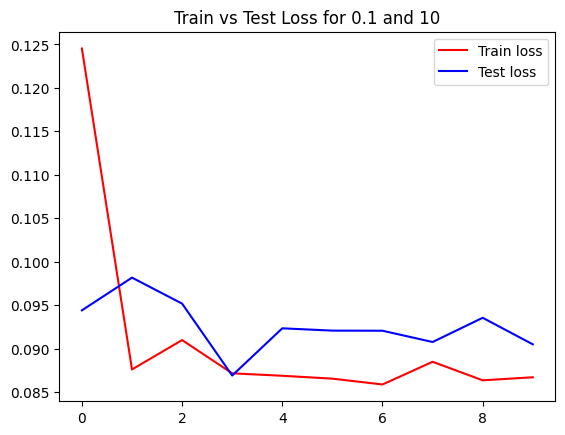

In [ ]:
# Tuning params
params = {
    "learning_rates": [0.1, 0.001, 0.0001, 0.00001],
    #"opts": ["Adam", "Nadam"],
    "epochs": [10, 30, 50],
    #"h_sizes": [16, 32, 64],
    #"layers": [1, 2, 4],
    #"dropouts": [0.3, 0.5, 0.7]
}

# Hyperparameter tuning
best_combo = None
previous_best = None

for lr in params['learning_rates']:
    for epoch in params['epochs']:

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        
        # Train model
        train_losses, test_losses = model.train_model(
            optimizer=optimizer,
            loss_fn=LOSS_FN,
            train_dataloader=train_dataloader,
            test_dataloader=test_dataloader,
            n_epochs=epoch
        )

        # For comparison
        plt.plot(train_losses, color="red", label="Train loss")
        plt.plot(test_losses, color="blue", label="Test loss")
        plt.legend()
        plt.title(f"Train vs Test Loss for {lr} and {epoch}")
        plt.savefig(f"tuning_graphs/loss_lr{lr}_epoch{epoch}.png")
        plt.close()

        # model evaluation
        rmse, mae = model.eval_model(test_dataloader)

        if best_combo == None or previous_best == None:
            best_combo = [lr, epoch]
            previous_best = rmse
        elif rmse < previous_best:
            best_combo = [lr, epoch]
            previous_best = rmse
        else:
            continue

print(f"""Best Hyperparameter setup: learning rate of {best_combo[0]} and epochs of {best_combo[1]}. 
      Achieved RMSE of {rmse}, and MAE of {mae} on test data.""")

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=best_combo[0])
num_epochs = best_combo[1]

# Train model
train_losses, test_losses = model.train_model(
    optimizer=optimizer,
    loss_fn=LOSS_FN,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    n_epochs=num_epochs
)

In [ ]:
# Evaluate test performance

rmse, mae = model.eval_model(test_dataloader)
print(rmse, mae)

Test RMSE: 0.24682310223579407
Test MAE: 0.18535436689853668


(0.24682310223579407, 0.18535436689853668)

RMSE: 0.3641050457954407
MAE: 0.33480104804039
goals_per_90 RMSE: 0.6767855286598206
goals_per_90 MAE: 0.613333523273468
xG_per_90 RMSE: 0.6809220314025879
xG_per_90 MAE: 0.6655443906784058
assists_per_90 RMSE: 0.16036587953567505
assists_per_90 MAE: 0.12379850447177887
xA_per_90 RMSE: 0.07983393967151642
xA_per_90 MAE: 0.06405650079250336
key_passes_per_90 RMSE: 0.37651023268699646
key_passes_per_90 MAE: 0.32978975772857666
xGChain_per_90 RMSE: 0.5105866193771362
xGChain_per_90 MAE: 0.4937995374202728
xGBuildup_per_90 RMSE: 0.06373108178377151
xGBuildup_per_90 MAE: 0.05328501760959625


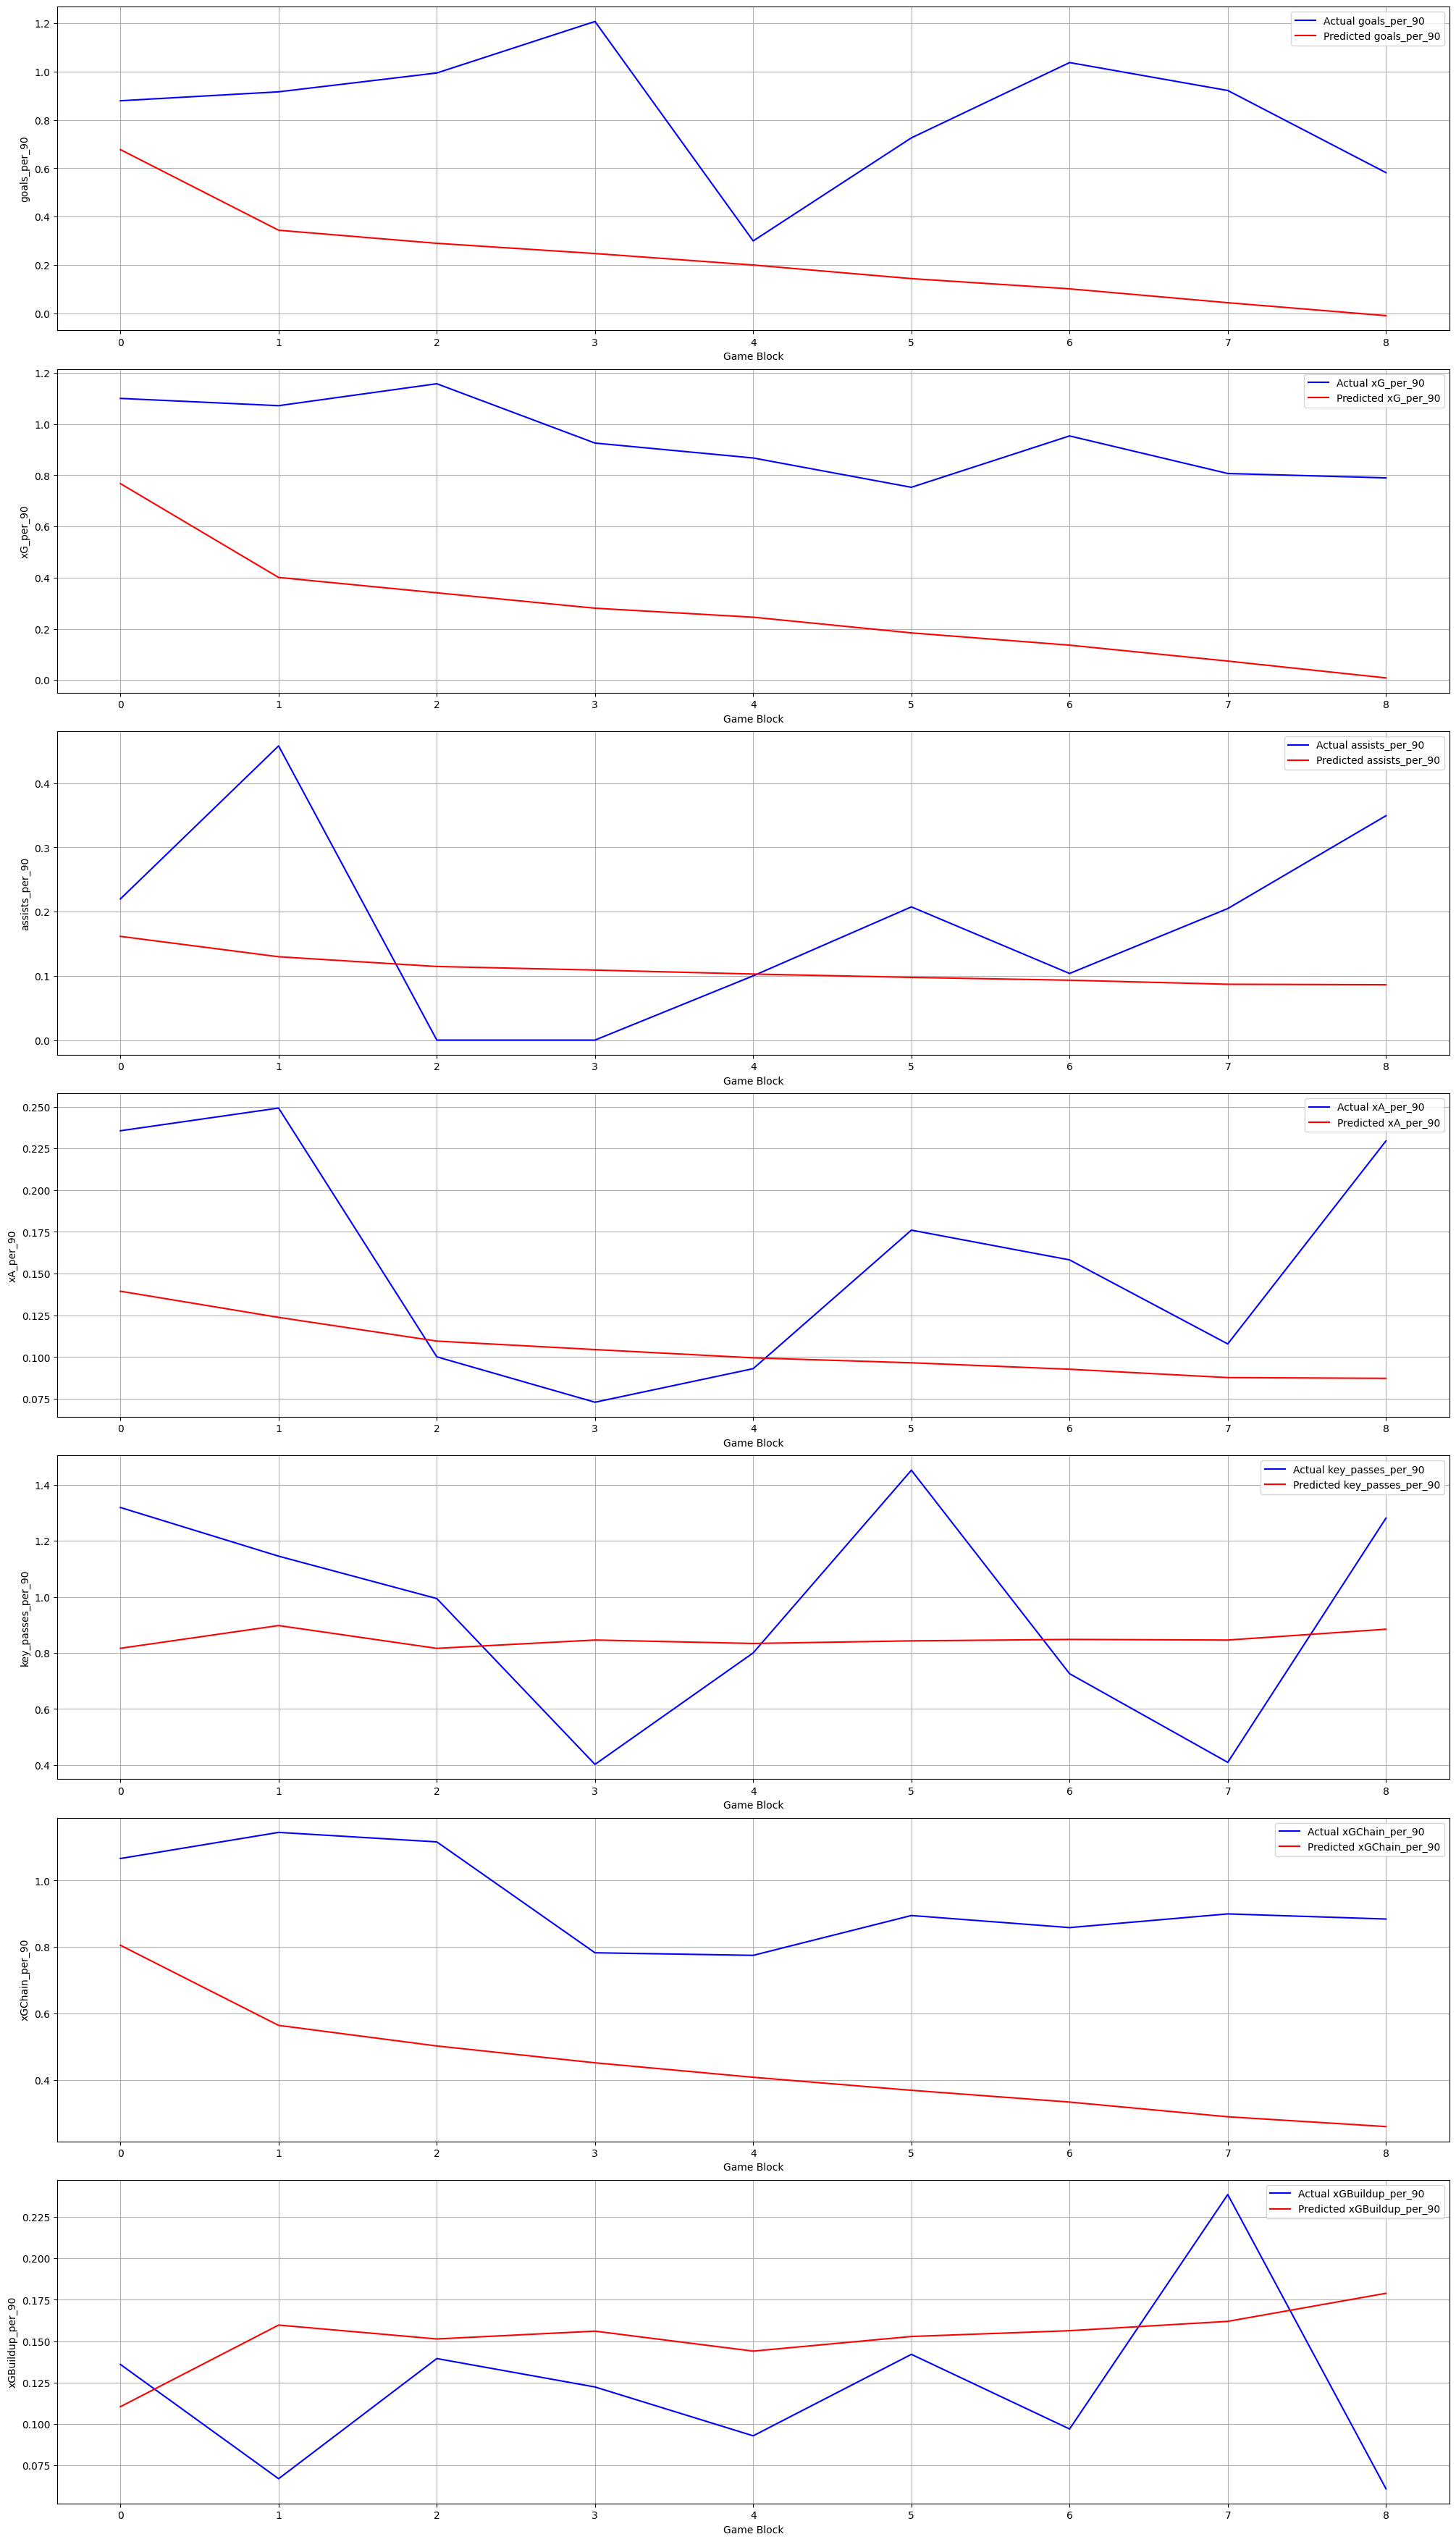

In [ ]:
# See how model does on forecasting a specific player--Erling Haaland

haaland_df = f_stats.loc["8260"]

model.eval_model_on_player(haaland_df)